In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [2]:
results_df = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Logistic Regression",
        "Random Forest"
    ],

    "Accuracy": [0.96,0.95,0.97],

    "Precision": [1.00,0.98,0.98],

    "Recall": [0.73,0.62,0.78],

    "F1": [0.84,0.76,0.87]
})

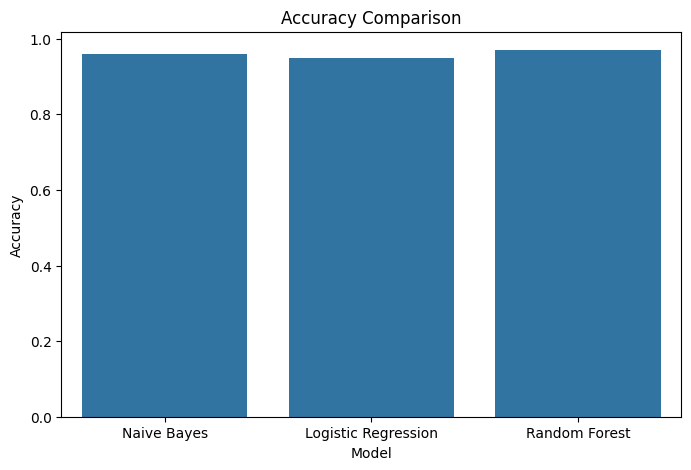

In [3]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy"
)

plt.title("Accuracy Comparison")

plt.show()

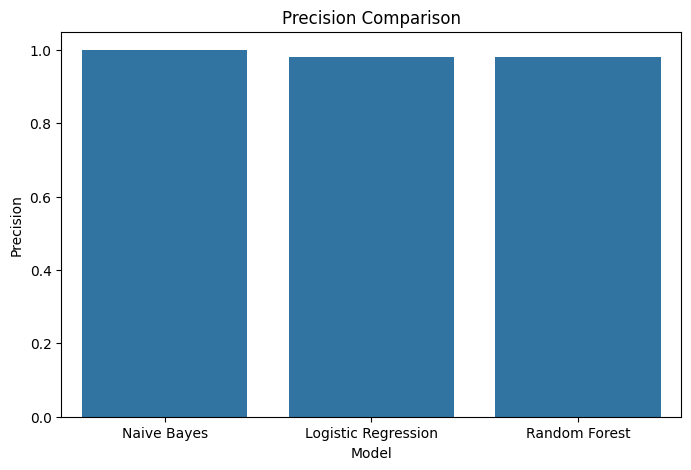

In [4]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Precision"
)

plt.title("Precision Comparison")

plt.show()

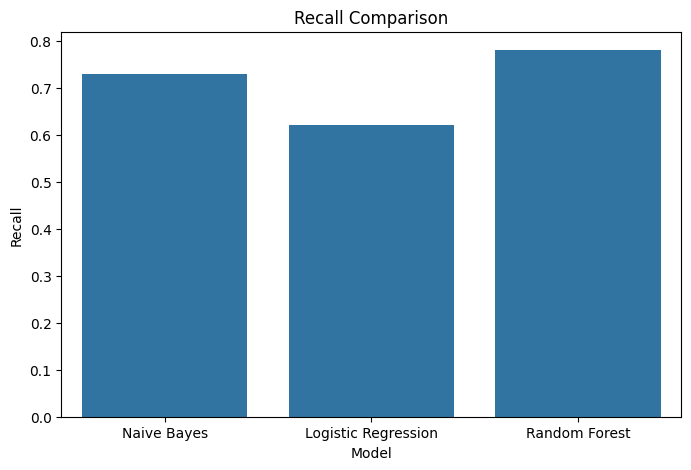

In [5]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Recall"
)

plt.title("Recall Comparison")

plt.show()

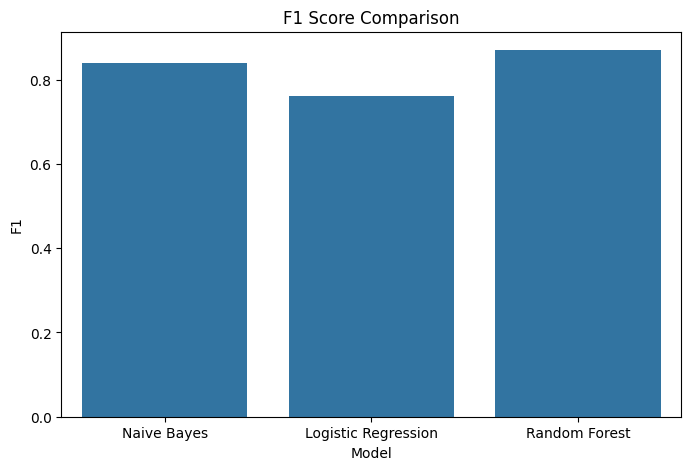

In [6]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="F1"
)

plt.title("F1 Score Comparison")

plt.show()

In [7]:
import pickle

with open("../models/logistic_regression.pkl","rb") as f:

    model = pickle.load(f)

In [12]:
df = pd.read_csv("../dataset/spam_processed.csv")

# Null values error fixed by filling with empty string
df["processed_message"] = (df["processed_message"].fillna(""))

with open("../models/tfidf_vectorizer.pkl","rb") as f:

    tfidf = pickle.load(f)

In [13]:
X = tfidf.transform(df["processed_message"])

y = df["label"]

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [15]:
y_pred = model.predict(X_test)

In [16]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

cm

array([[677,   1],
       [ 37,  61]])

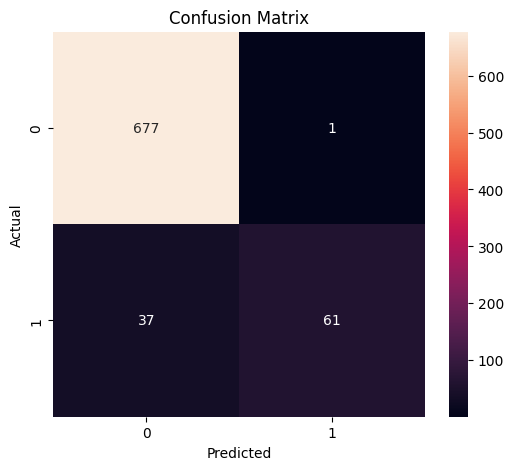

In [17]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()